# Tutorial: Data Bootstrapping With Block Bootstrap

This notebook is the practical version of the data-bootstrapping guide. It shows how to create artificial OHLC paths from a real dataframe using `haymaker.research.bootstrap.bootstrap`.

Use this while developing a strategy, not as final proof. The synthetic paths are useful because they give you many plausible rearrangements of historical behavior. They are risky because they still come from the original sample and cannot invent market events that are missing from that sample.

The generated paths keep the same index length as the input after the first anchor row: `data.index[1:]`.

## Data source

The examples use continuous NQ futures from the local Arctic store:

```python
store = ArcticStore("contfutures")
df = store.store.read("NQ")
df = df.loc["2023-06-01":]
```

Any other OHLC dataframe can be substituted. The examples expect at least `open`, `high`, `low`, and `close`; `volume` and `barCount` are used when available.

## At-a-glance review

- Problem: one historical path is too easy to over-fit. Bootstrap paths give extra practice paths before the final real holdout test.
- Rule of thumb: develop on a training slice, generate synthetic paths from that slice, and keep unseen real data for the final check.
- Method used here: block bootstrap. Instead of shuffling single bars, it resamples runs of neighboring bars so short-term sequence is not immediately destroyed.
- Main risk: generated data is derived from the source data. It is helpful stress data, not independent evidence.
- Output contract: every call returns a `list[pd.DataFrame]`, even when `paths=1`.

In [1]:
import numpy as np
import pandas as pd

from haymaker.datastore import ArcticStore

store = ArcticStore("contfutures")
item = store.store.read("NQ")
df = item.data if hasattr(item, "data") else item
df = df.loc["2023-06-01":].copy()
df = df.sort_index()

df.head()

/home/tomek/.virtualenvs/new_ib/lib/python3.12/site-packages/arctic/__init__.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution
Library created, but couldn't enable sharding: no such command: 'enablesharding', full error: {'ok': 0.0, 'errmsg': "no such command: 'enablesharding'", 'code': 59, 'codeName': 'CommandNotFound'}. This is OK if you're not 'admin'


,open,high,low,close,volume,average,barCount
date,,,,,,,
2023-06-01 00:00:00+00:00,17073.25,17073.50,17070.75,17072.75,81.0,17072.125,65
2023-06-01 00:00:30+00:00,17072.25,17072.50,17071.25,17071.25,13.0,17071.925,10
2023-06-01 00:01:00+00:00,17071.00,17072.75,17067.75,17070.00,82.0,17069.975,53
2023-06-01 00:01:30+00:00,17069.75,17070.25,17068.25,17069.75,61.0,17069.050,48
2023-06-01 00:02:00+00:00,17070.50,17073.50,17070.50,17072.75,59.0,17072.375,45


In [2]:
required = ["open", "high", "low", "close"]
optional = [column for column in ["volume", "barCount", "average"] if column in df.columns]
df = df[required + optional].dropna().copy()

# The NQ 30-second slice is large. Keep the tutorial responsive; set this
# to None if you want to run every example on the full history.
max_rows = 100_000
if max_rows is not None and len(df) > max_rows:
    df = df.tail(max_rows).copy()

df.tail()

,open,high,low,close,volume,barCount,average
date,,,,,,,
2026-03-24 08:32:30+00:00,24405.00,24407.25,24395.50,24398.50,100.0,65,24403.250
2026-03-24 08:33:00+00:00,24401.50,24404.75,24395.50,24397.75,57.0,46,24400.575
2026-03-24 08:33:30+00:00,24396.25,24402.25,24385.25,24387.25,78.0,60,24394.300
2026-03-24 08:34:00+00:00,24387.75,24395.75,24387.75,24391.75,39.0,35,24392.900
2026-03-24 08:34:30+00:00,24391.25,24399.25,24391.25,24396.00,31.0,26,24395.875


## Generate default stationary-bootstrap paths

The default one-liner is usually enough to start:

```python
synthetic = bootstrap(df, paths=3, random_state=42)
```

That means `method="stationary"` and `block_length="auto"`. Stationary bootstrap uses variable-length blocks; the automatic block length uses `arch` when installed and an internal fallback otherwise.

In [ ]:
from haymaker.research.bootstrap import bootstrap, optimal_block_length

log_returns = np.log(df["close"] / df["close"].shift()).dropna()
print("Estimated stationary block length:", optimal_block_length(log_returns))

synthetic = bootstrap(df, paths=3, random_state=42)

synthetic[0].head()

## Compare block methods

- `stationary`: variable-length blocks with random jumps; best default for exploratory work.
- `moving`: fixed-length blocks that do not wrap; useful when you want blocks to stay fully inside the original sample.
- `circular`: fixed-length blocks that may wrap from the end of the sample to the beginning.

Changing the method changes what structure is preserved. None of the methods covers events that are absent from the source data.

In [4]:
method_paths = {
    method: bootstrap(
        df,
        method=method,
        block_length=100,
        paths=1,
        random_state=42,
    )[0]
    for method in ["stationary", "moving", "circular"]
}

pd.DataFrame(
    {
        method: path["close"].pct_change().describe()
        for method, path in method_paths.items()
    }
)

,stationary,moving,circular
count,9.999800e+04,9.999800e+04,99998.000000
mean,3.275741e-07,-5.376792e-07,-0.000003
std,2.952960e-04,2.856887e-04,0.000290
min,-1.154136e-02,-1.154136e-02,-0.011541
25%,-1.199232e-04,-1.170677e-04,-0.000119
50%,0.000000e+00,0.000000e+00,0.000000
75%,1.193682e-04,1.109162e-04,0.000110
max,9.008255e-03,9.008255e-03,0.009008


## Plot generated paths

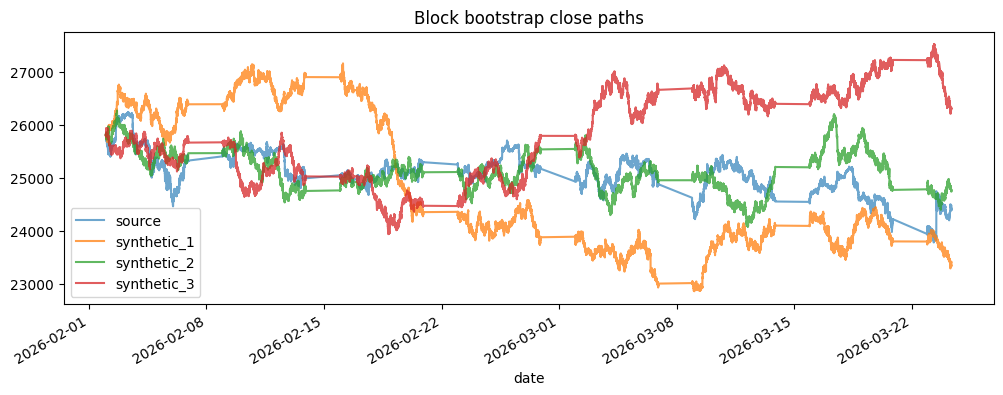

In [5]:
ax = df["close"].iloc[1:].rename("source").plot(
    figsize=(12, 4),
    alpha=0.65,
    grid=True,
    title="Block bootstrap close paths",
)
for number, path in enumerate(synthetic, start=1):
    path["close"].rename(f"synthetic_{number}").plot(ax=ax, alpha=0.75)
ax.legend()

## Output contract

All generated paths are ordinary OHLC dataframes. They can be passed into the same research functions as historical data.

Important details to remember:

- `synthetic` is a list, so use `synthetic[0]` for the first generated path.
- Each path is indexed like `df.index[1:]` and has `len(df) - 1` rows.
- The first real close anchors reconstruction; generated bars are then chained from synthetic closes.
- Unknown columns are dropped unless you intentionally pass them as `raw_columns`.

In [6]:
print(type(synthetic), len(synthetic))
print(synthetic[0].index.equals(df.index[1:]))
synthetic[0].tail()

<class 'list'> 3
True


,open,high,low,close,volume,barCount
date,,,,,,
2026-03-24 08:32:30+00:00,23334.447086,23334.917918,23330.915844,23332.799173,42.0,35
2026-03-24 08:33:00+00:00,23331.575267,23413.577005,23329.861798,23411.863536,1007.0,763
2026-03-24 08:33:30+00:00,23413.977665,23418.910633,23412.803149,23416.091794,45.0,40
2026-03-24 08:34:00+00:00,23416.561516,23418.910124,23408.576248,23410.924856,65.0,58
2026-03-24 08:34:30+00:00,23409.992512,23409.992512,23405.563878,23406.729308,8.0,8


## Quick exercise

Try a smaller fixed block length and compare the volatility of the generated close-to-close returns. If the synthetic paths look too smooth or too jumpy, block length is one of the first knobs to inspect.

In [ ]:
exercise_paths = bootstrap(df, block_length=50, paths=5, random_state=123)

pd.Series(
    [path["close"].pct_change().std() for path in exercise_paths],
    name="synthetic_return_volatility",
)